### Imports

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from zero_point import zpt

zpt.load_tables()

### Load All Data

In [3]:
data_folder = '/Users/philvanlane/Documents/lc_ae/data/'

In [6]:
data = pd.read_csv(data_folder + 'moca_add_old_dr3.csv',dtype={'Gaiadr3_id': 'string'})

In [7]:
data

,Gaiadr3_id,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,bp_rp,phot_g_mean_mag,...,pmra_error,pmdec,pmdec_error,radial_velocity,radial_velocity_error,ruwe,nu_eff_used_in_astrometry,pseudocolour,ecl_lat,astrometric_params_solved
0,3218825173693891968,3218825173693891968,88.410003,0.016051,0.210381,0.014464,0.847841,0.019616,1.471010,14.297590,...,0.021058,4.132852,0.017568,27.386599,4.535599,1.030627,1.425565,NaN,-23.219351,31
1,3218833145153121920,3218833145153121920,88.426305,0.015183,0.412969,0.014403,0.881114,0.019391,1.456237,14.222679,...,0.018779,4.408149,0.017180,NaN,NaN,1.007080,1.428510,NaN,-23.016972,31
2,3341826336904947456,3341826336904947456,90.720776,0.039883,10.515080,0.034259,0.240730,0.051409,1.154162,15.836431,...,0.047484,-0.680543,0.036709,NaN,NaN,0.959869,1.486723,NaN,-12.922382,31
3,5538869264640087040,5538869264640087040,118.018587,0.024036,-38.549179,0.026863,0.686976,0.028933,1.109064,15.761438,...,0.032476,0.684120,0.032134,NaN,NaN,0.952062,1.495015,NaN,-57.821348,31
4,2051294423734922112,2051294423734922112,290.178038,0.010583,37.852057,0.012992,0.231542,0.013447,1.499000,14.126417,...,0.013367,-2.251944,0.016424,-49.364223,2.088465,1.090410,1.416156,NaN,59.070092,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3422,3028600659848440192,3028600659848440192,112.132747,0.048788,-15.371448,0.049397,0.243959,0.073693,1.368328,16.996632,...,0.060439,1.621755,0.057660,NaN,NaN,0.981669,1.450309,NaN,-36.761642,31
3423,3426177329934923648,3426177329934923648,91.865811,0.040324,24.078522,0.034361,0.165280,0.044378,1.328260,15.947637,...,0.049967,-1.951594,0.035296,NaN,NaN,1.008758,1.452606,NaN,0.650274,31
3424,3426182788837695232,3426182788837695232,91.713961,0.067003,24.200282,0.057166,0.180040,0.075159,1.322140,16.963383,...,0.082088,-1.974735,0.062617,NaN,NaN,0.963671,1.449945,NaN,0.770303,31
3425,2893942714871386240,2893942714871386240,97.379667,0.035816,-31.278675,0.040009,0.234967,0.049104,0.768299,16.909206,...,0.051838,5.405890,0.050884,NaN,NaN,1.003146,1.569814,NaN,-54.439578,31


### Zeropoint Corrections

In [8]:
for i,r in data.iterrows():
    try:
        corr = zpt.get_zpt(
            r.phot_g_mean_mag,
            r.nu_eff_used_in_astrometry,
            r.pseudocolour,
            r.ecl_lat,
            r.astrometric_params_solved)
    except:
        corr = float('nan')
    data.at[i,'zpt_corr'] = corr

/Users/philvanlane/opt/anaconda3/envs/default-py312/lib/python3.12/site-packages/zero_point/zpt.py:243: UserWarning: The pseudocolour of some of the 6p source(s) is outside the expected range (1.24-1.72 mag).
                 The maximum corrections are reached already at 1.24 and 1.72
  warnings.warn(


In [9]:
data['parallax_zpt_corrected'] = data['parallax'] - data['zpt_corr']

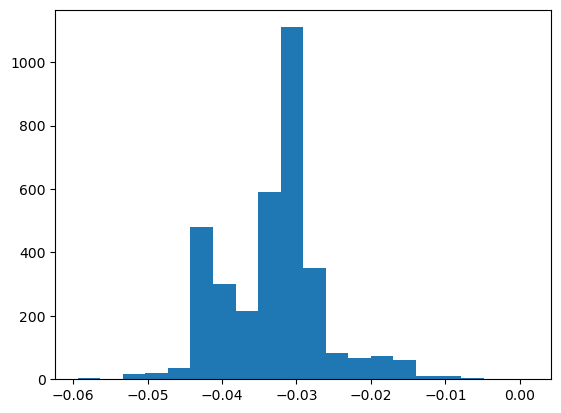

In [10]:
plt.hist(data['zpt_corr'].values,bins=20)
plt.show()

In [8]:
data

,Gaiadr3_id,source_id,ra,ra_error,dec,dec_error,parallax,parallax_error,bp_rp,phot_g_mean_mag,...,pmdec_error,radial_velocity,radial_velocity_error,ruwe,nu_eff_used_in_astrometry,pseudocolour,ecl_lat,astrometric_params_solved,zpt_corr,parallax_zpt_corrected
0,6771939433131924096,6771939433131924096,294.306839,0.016671,-22.204488,0.015077,1.801801,0.018798,0.873712,12.974145,...,0.016994,-25.936798,1.839864,1.162623,1.542163,NaN,-0.635815,31,-0.034449,1.836250
1,2051947739803854336,2051947739803854336,292.587774,0.010769,38.521982,0.013136,1.124761,0.013677,0.871462,14.067142,...,0.016678,-54.441850,3.800735,0.989026,1.543793,NaN,59.177397,31,-0.027925,1.152686
2,2130377106797534336,2130377106797534336,287.968099,0.020586,46.470596,0.021622,1.648134,0.022772,1.316242,15.454608,...,0.026719,NaN,NaN,1.021167,1.449166,NaN,67.788088,31,-0.025904,1.674038
3,4525545299652540672,4525545299652540672,276.810046,0.006449,20.526888,0.010527,5.091625,0.012540,0.962543,10.672528,...,0.012120,-108.546650,0.172836,1.002895,1.522600,NaN,43.757313,31,-0.024224,5.115849
4,1816307623283205248,1816307623283205248,305.459061,0.196676,19.435845,0.313800,-0.201572,0.323614,NaN,18.618368,...,0.385505,NaN,NaN,1.002529,NaN,1.391204,37.649632,95,-0.021529,-0.180043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4229,2125773279815846656,2125773279815846656,291.960661,0.011566,42.432956,0.013108,1.059101,0.014106,0.861845,14.097954,...,0.015360,-92.417530,4.677284,1.019613,1.543823,NaN,63.041334,31,-0.026838,1.085939
4230,2077617930392844800,2077617930392844800,293.758299,0.009333,41.871805,0.010434,1.075522,0.011846,1.250227,12.421128,...,0.013071,-54.508250,0.373680,0.986706,1.459771,NaN,62.065890,31,-0.009561,1.085083
4231,2106043093408840960,2106043093408840960,287.593199,0.016048,44.179428,0.019168,1.238529,0.019413,1.080882,15.061457,...,0.023275,NaN,NaN,0.917640,1.494734,NaN,65.689427,31,-0.025948,1.264477
4232,2127132821641254272,2127132821641254272,288.971633,0.095474,44.624648,0.118298,1.403393,0.114990,0.932277,12.245716,...,0.138360,-25.471807,0.872108,12.490296,1.528492,NaN,65.814347,31,-0.012838,1.416231


In [9]:
# output = data[['Gaiadr3_id','parallax','zpt_corr','parallax_zpt_corrected']]
data.to_csv(data_folder + 'host_dr3_zpt.csv', index=False)

In [12]:
output.to_csv(data_folder + 'dr3_zpt_only.csv')